# Занятие 3. Transfer Learning с CNN (ResNet, DenseNet, EfficientNet)
## Нейросетевые методы обработки изображений

В этом ноутбуке мы:
1. Загрузим предобученные ResNet-18, DenseNet-121, EfficientNet-B0.
2. Реализуем три режима: Feature Extraction, Fine-tuning, From Scratch.
3. Обучим все варианты на компактном датасете (CIFAR-10).
4. Сравним accuracy/precision/recall/F1 и confusion matrix.

---
## Шаг 1. Импорты и проверка GPU

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.optim import lr_scheduler
from torch.utils.data import DataLoader, Subset
import torchvision
import torchvision.transforms as transforms
import torchvision.models as models
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import time

# Устройство: GPU если есть, иначе CPU
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'PyTorch: {torch.__version__}')
print(f'Устройство: {device}')
if device.type == 'cuda':
    print(f'GPU: {torch.cuda.get_device_name(0)}')
    print(f'Память GPU: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')

PyTorch: 2.13.0+cpu
Устройство: cpu


---
## Шаг 2. Датасет и DataLoader

Используем CIFAR-10 (60 000 изображений 32x32, 10 классов).

Важно: предобученные ImageNet-модели ожидают вход 224x224.
ImageNet mean/std: mean=(0.485,0.456,0.406), std=(0.229,0.224,0.225).

Для быстрой демонстрации берём подвыборку (2000 train / 1000 val).
Уберите Subset чтобы обучать на полном датасете.

In [2]:
IMAGENET_MEAN = (0.485, 0.456, 0.406)
IMAGENET_STD  = (0.229, 0.224, 0.225)

# train: с аугментациями
train_transform = transforms.Compose([
    transforms.Resize(224),
    transforms.RandomCrop(224, padding=8),
    transforms.RandomHorizontalFlip(0.5),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

# val: только предобработка, детерминированная
val_transform = transforms.Compose([
    transforms.Resize(224),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

train_ds_full = torchvision.datasets.CIFAR10(root='./cifar', train=True,  download=False,  transform=train_transform)
val_ds_full   = torchvision.datasets.CIFAR10(root='./cifar', train=False, download=False, transform=val_transform)

# Подвыборка для быстрой демонстрации.
# Для полного обучения используйте train_ds_full и val_ds_full напрямую.
train_ds = Subset(train_ds_full, list(range(2000)))
val_ds   = Subset(val_ds_full,   list(range(1000)))

train_loader = DataLoader(train_ds, batch_size=32, shuffle=True,  num_workers=0)
val_loader   = DataLoader(val_ds,   batch_size=32, shuffle=False, num_workers=0)

CLASS_NAMES = train_ds_full.classes
NUM_CLASSES  = len(CLASS_NAMES)
print(f'Классы ({NUM_CLASSES}): {CLASS_NAMES}')
print(f'Train: {len(train_ds)}, Val: {len(val_ds)}')

Классы (10): ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']
Train: 2000, Val: 1000


---
## Шаг 3. Вспомогательные функции обучения

In [3]:
def train_epoch(model, loader, criterion, optimizer):
    """Один проход по train-выборке. Возвращает loss и accuracy."""
    model.train()
    total_loss, correct, total = 0.0, 0, 0
    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * images.size(0)
        _, preds = outputs.max(1)
        correct += preds.eq(labels).sum().item()
        total   += labels.size(0)
    return total_loss / total, correct / total


def eval_epoch(model, loader, criterion):
    """Один проход по val-выборке. Возвращает loss, accuracy и предсказания."""
    model.eval()
    total_loss, correct, total = 0.0, 0, 0
    all_preds, all_labels = [], []
    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            total_loss += loss.item() * images.size(0)
            _, preds = outputs.max(1)
            correct += preds.eq(labels).sum().item()
            total   += labels.size(0)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    return total_loss / total, correct / total, all_preds, all_labels


def run_training(model, name, num_epochs=5, lr=1e-3):
    """Обучает модель num_epochs эпох. Возвращает модель и историю."""
    model = model.to(device)
    criterion = nn.CrossEntropyLoss()
    # filter(requires_grad): оптимизируем только разморозированные параметры
    optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=lr)
    # ReduceLROnPlateau: уменьшает lr в 10 раз при отсутствии улучшения val_loss
    scheduler = lr_scheduler.ReduceLROnPlateau(optimizer, patience=2, factor=0.1)
    history = {'train_loss':[], 'val_loss':[], 'train_acc':[], 'val_acc':[]}
    t0 = time.time()
    for epoch in range(num_epochs):
        tr_loss, tr_acc = train_epoch(model, train_loader, criterion, optimizer)
        vl_loss, vl_acc, _, _ = eval_epoch(model, val_loader, criterion)
        scheduler.step(vl_loss)
        history['train_loss'].append(tr_loss)
        history['val_loss'].append(vl_loss)
        history['train_acc'].append(tr_acc)
        history['val_acc'].append(vl_acc)
        print(f'  [{name}] Epoch {epoch+1}/{num_epochs} | train acc={tr_acc:.3f} | val acc={vl_acc:.3f}')
    print(f'  Время {name}: {time.time()-t0:.1f} сек')
    return model, history

print('Функции train_epoch, eval_epoch, run_training определены.')

Функции train_epoch, eval_epoch, run_training определены.


---
## Шаг 4. Режим 1: Feature Extraction

Загружаем ResNet-18 с весами ImageNet, замораживаем все слои,
заменяем только последний FC-слой.

requires_grad=False: PyTorch не вычисляет градиенты для этих параметров.

In [4]:
# Загрузка ResNet-18 с предобученными весами ImageNet
model_fe = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)

# --- Заморозить все слои ---
for param in model_fe.parameters():
    param.requires_grad = False  # градиенты не вычисляются, веса не обновляются

# --- Заменить последний FC-слой ---
# По умолчанию: Linear(512, 1000) для 1000 классов ImageNet
# Нам нужно: Linear(512, NUM_CLASSES)
num_features = model_fe.fc.in_features  # 512 для ResNet-18
model_fe.fc = nn.Linear(num_features, NUM_CLASSES)
# Новый fc автоматически имеет requires_grad=True

trainable = sum(p.numel() for p in model_fe.parameters() if p.requires_grad)
total     = sum(p.numel() for p in model_fe.parameters())
print(f'Feature Extraction (ResNet-18):')
print(f'  Обучаемые параметры: {trainable:,} / {total:,} ({trainable/total*100:.1f}%)')

print('\nОбучение Feature Extraction...')
model_fe, hist_fe = run_training(model_fe, 'FeatureExtract', num_epochs=5, lr=1e-3)

Feature Extraction (ResNet-18):
  Обучаемые параметры: 5,130 / 11,181,642 (0.0%)

Обучение Feature Extraction...
  [FeatureExtract] Epoch 1/5 | train acc=0.342 | val acc=0.599
  [FeatureExtract] Epoch 2/5 | train acc=0.634 | val acc=0.715
  [FeatureExtract] Epoch 3/5 | train acc=0.688 | val acc=0.698
  [FeatureExtract] Epoch 4/5 | train acc=0.732 | val acc=0.737
  [FeatureExtract] Epoch 5/5 | train acc=0.744 | val acc=0.745
  Время FeatureExtract: 341.0 сек


---
## Шаг 5. Режим 2: Fine-Tuning (частичный)

Замораживаем layer1-3, размораживаем layer4 + FC.
Для layer4 используем маленький lr (1e-4), для FC — большой (1e-3).

Это позволяет адаптировать высокоуровневые признаки к новой задаче,
не трогая низкоуровневые (края, текстуры).

In [5]:
model_ft = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)

# 1. Сначала заморозить всё
for param in model_ft.parameters():
    param.requires_grad = False

# 2. Разморозить layer4 -- последний residual блок
for param in model_ft.layer4.parameters():
    param.requires_grad = True

# 3. Заменить FC
model_ft.fc = nn.Linear(model_ft.fc.in_features, NUM_CLASSES)

trainable = sum(p.numel() for p in model_ft.parameters() if p.requires_grad)
total     = sum(p.numel() for p in model_ft.parameters())
print(f'Fine-Tuning частичный (ResNet-18):')
print(f'  Обучаемые параметры: {trainable:,} / {total:,} ({trainable/total*100:.1f}%)')

model_ft = model_ft.to(device)
criterion_ft = nn.CrossEntropyLoss()
# Разные lr для backbone и head
optimizer_ft = optim.Adam([
    {'params': model_ft.layer4.parameters(), 'lr': 1e-4},  # backbone: lr маленький
    {'params': model_ft.fc.parameters(),     'lr': 1e-3},  # head: lr большой
])
scheduler_ft = lr_scheduler.ReduceLROnPlateau(optimizer_ft, patience=2, factor=0.1)

hist_ft = {'train_loss':[], 'val_loss':[], 'train_acc':[], 'val_acc':[]}
t0 = time.time()
for epoch in range(5):
    tr_loss, tr_acc = train_epoch(model_ft, train_loader, criterion_ft, optimizer_ft)
    vl_loss, vl_acc, _, _ = eval_epoch(model_ft, val_loader, criterion_ft)
    scheduler_ft.step(vl_loss)
    hist_ft['train_loss'].append(tr_loss); hist_ft['val_loss'].append(vl_loss)
    hist_ft['train_acc'].append(tr_acc);   hist_ft['val_acc'].append(vl_acc)
    print(f'  [FineTune] Epoch {epoch+1}/5 | train={tr_acc:.3f} | val={vl_acc:.3f}')
print(f'  Время: {time.time()-t0:.1f} сек')

Fine-Tuning частичный (ResNet-18):
  Обучаемые параметры: 8,398,858 / 11,181,642 (75.1%)
  [FineTune] Epoch 1/5 | train=0.613 | val=0.774
  [FineTune] Epoch 2/5 | train=0.856 | val=0.819
  [FineTune] Epoch 3/5 | train=0.902 | val=0.844
  [FineTune] Epoch 4/5 | train=0.944 | val=0.847
  [FineTune] Epoch 5/5 | train=0.959 | val=0.849
  Время: 411.0 сек


---
## Шаг 6. Режим 3: From Scratch (обучение с нуля)

Загружаем ту же архитектуру ResNet-18, но weights=None.
Все параметры инициализируются случайно (Xavier/He по умолчанию).

Это базовая линия для оценки пользы transfer learning.

In [6]:
# weights=None: случайная инициализация, никаких предобученных весов
model_scratch = models.resnet18(weights=None)
model_scratch.fc = nn.Linear(model_scratch.fc.in_features, NUM_CLASSES)

trainable = sum(p.numel() for p in model_scratch.parameters() if p.requires_grad)
print(f'From Scratch (ResNet-18):')
print(f'  Обучаемых параметров: {trainable:,} (все слои)')

print('\nОбучение From Scratch...')
model_scratch, hist_scratch = run_training(model_scratch, 'Scratch', num_epochs=5, lr=1e-3)

From Scratch (ResNet-18):
  Обучаемых параметров: 11,181,642 (все слои)

Обучение From Scratch...
  [Scratch] Epoch 1/5 | train acc=0.215 | val acc=0.265
  [Scratch] Epoch 2/5 | train acc=0.281 | val acc=0.240
  [Scratch] Epoch 3/5 | train acc=0.317 | val acc=0.373
  [Scratch] Epoch 4/5 | train acc=0.332 | val acc=0.346
  [Scratch] Epoch 5/5 | train acc=0.378 | val acc=0.335
  Время Scratch: 704.2 сек


---
## Шаг 7. Режим 4: Full Fine-Tuning

Размораживаем всю сеть, используем маленький lr для всего backbone.

In [7]:
model_full = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)
model_full.fc = nn.Linear(model_full.fc.in_features, NUM_CLASSES)

# Все параметры обучаемы (requires_grad=True по умолчанию после загрузки)
trainable = sum(p.numel() for p in model_full.parameters() if p.requires_grad)
print(f'Full Fine-Tuning (ResNet-18):')
print(f'  Обучаемых параметров: {trainable:,} (все слои)')
print(f'  Используем маленький lr=1e-4 для всей сети')

print('\nОбучение Full Fine-Tuning...')
# lr маленький: backbone уже хорошо обучен на ImageNet, не хотим сильно менять веса
model_full, hist_full = run_training(model_full, 'FullFT', num_epochs=5, lr=1e-4)

Full Fine-Tuning (ResNet-18):
  Обучаемых параметров: 11,181,642 (все слои)
  Используем маленький lr=1e-4 для всей сети

Обучение Full Fine-Tuning...
  [FullFT] Epoch 1/5 | train acc=0.637 | val acc=0.777
  [FullFT] Epoch 2/5 | train acc=0.871 | val acc=0.808
  [FullFT] Epoch 3/5 | train acc=0.936 | val acc=0.854
  [FullFT] Epoch 4/5 | train acc=0.971 | val acc=0.859
  [FullFT] Epoch 5/5 | train acc=0.980 | val acc=0.855
  Время FullFT: 706.2 сек


---
## Шаг 8. Визуализация кривых обучения

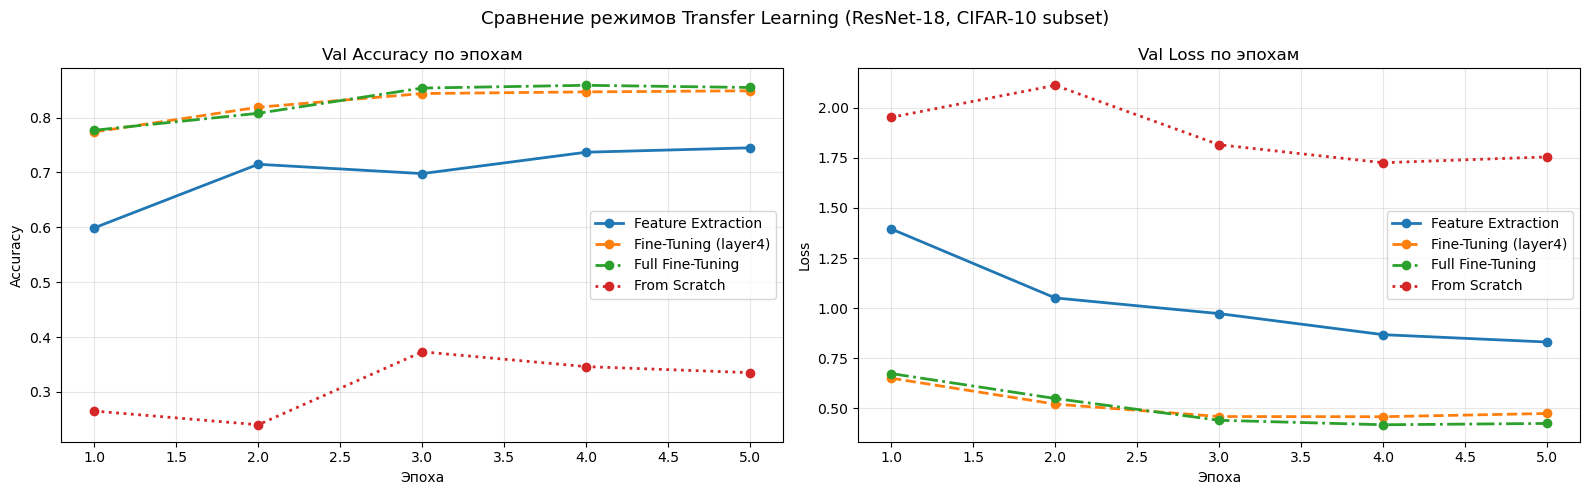

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

configs = [
    (hist_fe,     'Feature Extraction',  '#1f77b4', '-'),
    (hist_ft,     'Fine-Tuning (layer4)', '#ff7f0e', '--'),
    (hist_full,   'Full Fine-Tuning',     '#2ca02c', '-.'),
    (hist_scratch,'From Scratch',         '#d62728', ':'),
]
ep = range(1, 6)

for hist, name, color, style in configs:
    axes[0].plot(ep, hist['val_acc'], label=name, color=color, ls=style, lw=2, marker='o')
axes[0].set_title('Val Accuracy по эпохам', fontsize=12)
axes[0].set_xlabel('Эпоха'); axes[0].set_ylabel('Accuracy')
axes[0].legend(); axes[0].grid(alpha=0.3)

for hist, name, color, style in configs:
    axes[1].plot(ep, hist['val_loss'], label=name, color=color, ls=style, lw=2, marker='o')
axes[1].set_title('Val Loss по эпохам', fontsize=12)
axes[1].set_xlabel('Эпоха'); axes[1].set_ylabel('Loss')
axes[1].legend(); axes[1].grid(alpha=0.3)

plt.suptitle('Сравнение режимов Transfer Learning (ResNet-18, CIFAR-10 subset)', fontsize=13)
plt.tight_layout()
plt.show()

---
## Шаг 9. Метрики: Precision, Recall, F1

classification_report из sklearn даёт полный отчёт по каждому классу.

In [9]:
criterion = nn.CrossEntropyLoss()

_, acc_fe,     preds_fe,     labels_true = eval_epoch(model_fe,     val_loader, criterion)
_, acc_ft,     preds_ft,     _           = eval_epoch(model_ft,     val_loader, criterion)
_, acc_full,   preds_full,   _           = eval_epoch(model_full,   val_loader, criterion)
_, acc_scratch,preds_scratch,_           = eval_epoch(model_scratch,val_loader, criterion)

print('=' * 60)
for name, preds, acc in [
    ('Feature Extraction',    preds_fe,     acc_fe),
    ('Fine-Tuning (partial)', preds_ft,     acc_ft),
    ('Full Fine-Tuning',      preds_full,   acc_full),
    ('From Scratch',          preds_scratch,acc_scratch),
]:
    print(f'\n--- {name} (Accuracy: {acc:.3f}) ---')
    print(classification_report(labels_true, preds, target_names=CLASS_NAMES, digits=3))


--- Feature Extraction (Accuracy: 0.745) ---
              precision    recall  f1-score   support

    airplane      0.769     0.680     0.722       103
  automobile      0.759     0.921     0.832        89
        bird      0.760     0.570     0.651       100
         cat      0.576     0.660     0.615       103
        deer      0.711     0.656     0.682        90
         dog      0.741     0.733     0.737        86
        frog      0.754     0.795     0.774       112
       horse      0.946     0.686     0.795       102
        ship      0.825     0.802     0.813       106
       truck      0.703     0.936     0.803       109

    accuracy                          0.745      1000
   macro avg      0.755     0.744     0.743      1000
weighted avg      0.755     0.745     0.743      1000


--- Fine-Tuning (partial) (Accuracy: 0.849) ---
              precision    recall  f1-score   support

    airplane      0.796     0.835     0.815       103
  automobile      0.900     0.910    

---
## Шаг 10. Confusion Matrix для лучшей модели

Confusion matrix показывает, какие классы путает модель.
Строки = реальные классы, столбцы = предсказанные.

Лучшая модель: Full Fine-Tuning (acc=0.855)


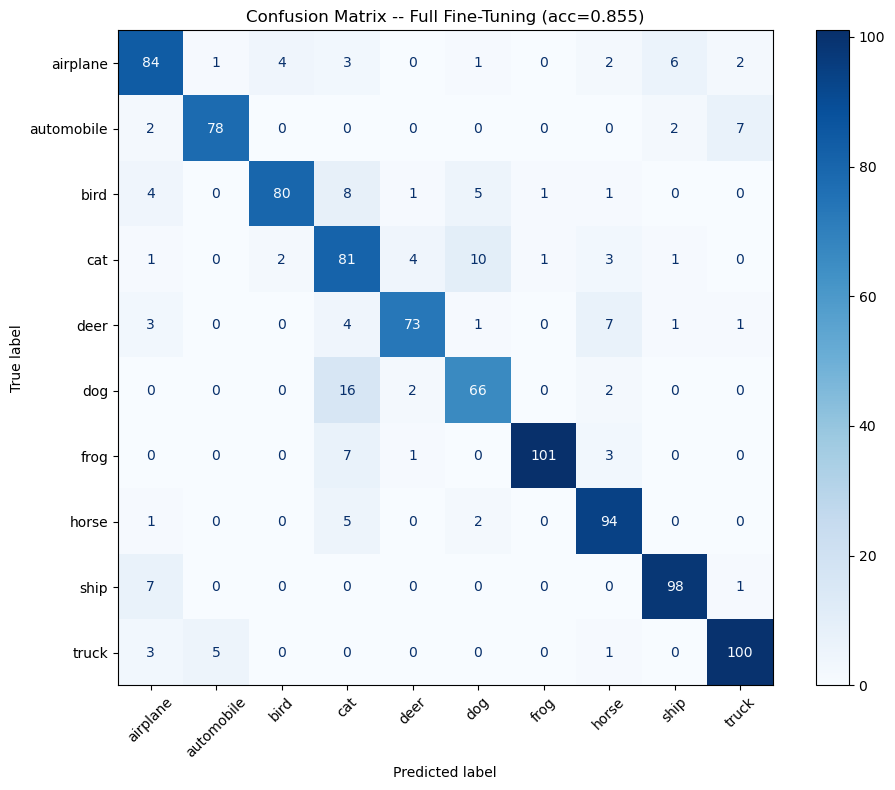


--- Сводная таблица ---
Full Fine-Tuning               | Accuracy: 0.855 <<< ЛУЧШИЙ
Fine-Tuning                    | Accuracy: 0.849
Feature Extraction             | Accuracy: 0.745
From Scratch                   | Accuracy: 0.335


In [10]:
results = [
    ('Feature Extraction', acc_fe,     preds_fe),
    ('Fine-Tuning',        acc_ft,     preds_ft),
    ('Full Fine-Tuning',   acc_full,   preds_full),
    ('From Scratch',       acc_scratch,preds_scratch),
]
best_name, best_acc, best_preds = max(results, key=lambda x: x[1])
print(f'Лучшая модель: {best_name} (acc={best_acc:.3f})')

cm = confusion_matrix(labels_true, best_preds)
fig, ax = plt.subplots(figsize=(10, 8))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=CLASS_NAMES)
disp.plot(ax=ax, colorbar=True, cmap='Blues', xticks_rotation=45)
ax.set_title(f'Confusion Matrix -- {best_name} (acc={best_acc:.3f})', fontsize=12)
plt.tight_layout()
plt.show()

print('\n--- Сводная таблица ---')
for name, acc, _ in sorted(results, key=lambda x: -x[1]):
    marker = ' <<< ЛУЧШИЙ' if name == best_name else ''
    print(f'{name:<30} | Accuracy: {acc:.3f}{marker}')

---
## Шаг 11. DenseNet-121 и EfficientNet-B0

Демонстрируем замену классификатора для DenseNet и EfficientNet.
Обратите внимание: имена атрибутов различаются у разных архитектур.

In [11]:
# --- DenseNet-121 ---
model_dense = models.densenet121(weights=models.DenseNet121_Weights.IMAGENET1K_V1)
for param in model_dense.parameters():
    param.requires_grad = False
# У DenseNet: model.classifier = Linear(1024, 1000)
in_dense = model_dense.classifier.in_features  # 1024
model_dense.classifier = nn.Linear(in_dense, NUM_CLASSES)
print(f'DenseNet-121: classifier.in_features={in_dense}, заморожен (кроме classifier)')

# --- EfficientNet-B0 ---
model_eff = models.efficientnet_b0(weights=models.EfficientNet_B0_Weights.IMAGENET1K_V1)
for param in model_eff.parameters():
    param.requires_grad = False
# У EfficientNet: model.classifier = Sequential(Dropout, Linear(1280, 1000))
# Нам нужен индекс [1] -- сам Linear слой
in_eff = model_eff.classifier[1].in_features  # 1280
model_eff.classifier[1] = nn.Linear(in_eff, NUM_CLASSES)
print(f'EfficientNet-B0: classifier[1].in_features={in_eff}, заморожен (кроме classifier[1])')

print('\nОбучение DenseNet-121...')
model_dense, hist_dense = run_training(model_dense, 'DenseNet-121', num_epochs=3, lr=1e-3)
print('\nОбучение EfficientNet-B0...')
model_eff, hist_eff = run_training(model_eff, 'EfficientNet-B0', num_epochs=3, lr=1e-3)

Downloading: "https://download.pytorch.org/models/densenet121-a639ec97.pth" to C:\Users\SNTkachenko/.cache\torch\hub\checkpoints\densenet121-a639ec97.pth


100%|█████████████████████████████████████████████████████████████████████████████| 30.8M/30.8M [00:01<00:00, 18.3MB/s]


DenseNet-121: classifier.in_features=1024, заморожен (кроме classifier)
Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to C:\Users\SNTkachenko/.cache\torch\hub\checkpoints\efficientnet_b0_rwightman-7f5810bc.pth


100%|█████████████████████████████████████████████████████████████████████████████| 20.5M/20.5M [00:01<00:00, 14.1MB/s]


EfficientNet-B0: classifier[1].in_features=1280, заморожен (кроме classifier[1])

Обучение DenseNet-121...
  [DenseNet-121] Epoch 1/3 | train acc=0.421 | val acc=0.587
  [DenseNet-121] Epoch 2/3 | train acc=0.695 | val acc=0.701
  [DenseNet-121] Epoch 3/3 | train acc=0.748 | val acc=0.744
  Время DenseNet-121: 719.2 сек

Обучение EfficientNet-B0...
  [EfficientNet-B0] Epoch 1/3 | train acc=0.449 | val acc=0.681
  [EfficientNet-B0] Epoch 2/3 | train acc=0.664 | val acc=0.740
  [EfficientNet-B0] Epoch 3/3 | train acc=0.703 | val acc=0.754
  Время EfficientNet-B0: 323.1 сек


---
## Шаг 12. Финальная сводная таблица

In [12]:
criterion = nn.CrossEntropyLoss()
_, acc_dense, _, _ = eval_epoch(model_dense, val_loader, criterion)
_, acc_eff,   _, _ = eval_epoch(model_eff,   val_loader, criterion)

all_results = [
    ('ResNet-18 Feature Extraction',  acc_fe,     '11.7M'),
    ('ResNet-18 Fine-Tuning partial', acc_ft,     '11.7M'),
    ('ResNet-18 Full Fine-Tuning',    acc_full,   '11.7M'),
    ('ResNet-18 From Scratch',        acc_scratch,'11.7M'),
    ('DenseNet-121 Feat. Extract.',   acc_dense,  '8.0M'),
    ('EfficientNet-B0 Feat. Extract.',acc_eff,    '5.3M'),
]
all_results.sort(key=lambda x: -x[1])

print(f"{'Модель':<40} | {'Val Acc':>8} | {'Params':>7}")
print('-' * 65)
for name, acc, params in all_results:
    print(f'{name:<40} | {acc:>8.3f} | {params:>7}')

print('\nВыводы:')
print('  1. Feature Extraction достигает приемлемой точности за секунды.')
print('  2. Fine-Tuning как правило превосходит Feature Extraction.')
print('  3. From Scratch значительно хуже при малом датасете (2000 примеров).')
print('  4. EfficientNet-B0: конкурентная точность при 5.3M параметров.')

Модель                                   |  Val Acc |  Params
-----------------------------------------------------------------
ResNet-18 Full Fine-Tuning               |    0.855 |   11.7M
ResNet-18 Fine-Tuning partial            |    0.849 |   11.7M
EfficientNet-B0 Feat. Extract.           |    0.754 |    5.3M
ResNet-18 Feature Extraction             |    0.745 |   11.7M
DenseNet-121 Feat. Extract.              |    0.744 |    8.0M
ResNet-18 From Scratch                   |    0.335 |   11.7M

Выводы:
  1. Feature Extraction достигает приемлемой точности за секунды.
  2. Fine-Tuning как правило превосходит Feature Extraction.
  3. From Scratch значительно хуже при малом датасете (2000 примеров).
  4. EfficientNet-B0: конкурентная точность при 5.3M параметров.


---
## Домашнее задание

1. **Основное.** Обучите ResNet-18 в трёх режимах на полном CIFAR-10 (50 000 train):
   - Feature Extraction (только FC)
   - Fine-Tuning (layer3+layer4+FC)
   - From Scratch
   Выведите classification_report и confusion matrix. Сравните результаты.

2. **Архитектуры.** Повторите эксперимент с DenseNet-121. Сравните с ResNet-18:
   - Время обучения на эпоху
   - Финальная accuracy
   - Число параметров

3. **Анализ ошибок.** Для лучшей модели найдите 5-10 примеров, где модель ошиблась.
   Выведите изображения, истинную и предсказанную метку.

4. **(Дополнительно)** Реализуйте progressive unfreezing:
   - Эпохи 1-2: только FC
   - Эпохи 3-4: layer4 + FC (lr_backbone=1e-4)
   - Эпохи 5-8: layer3+4 + FC (lr_backbone=1e-5)
   Сравните с обычным fine-tuning.

5. **(Дополнительно)** Подключите EfficientNet-B3 (input 300x300).
   Сравните с B0 по accuracy и скорости инференса.